# `LinearRegression`

In [156]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)

df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [157]:
df.shape

(20640, 9)

In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [159]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [160]:
data.target_names

['MedHouseVal']

`Samples = 2064`

`Features = ['MedHouseVal']`

`No missing values found` 

`The target = numerical --> Regression`

In [161]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [162]:
x = df.drop("MedHouseVal", axis =1)
y = df["MedHouseVal"]

In [163]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    train_size=0.2, #20% for testing
    random_state=42
)

In [164]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
learn = model.fit(x_train, y_train)
# I made my model learn the relationship between the trained data I selected

In [165]:
predictions = model.predict(x_test)
# Now, I wanna test my model

print(predictions)

[0.74240393 1.78093076 2.66354157 ... 1.4956322  2.10290312 2.23636156]


In [166]:
from sklearn.metrics import mean_absolute_error 

mae = mean_absolute_error(y_test, predictions)
mae

0.529593955305815

In [167]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
mse

0.5218435360402411

In [168]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, predictions)
rmse

0.722387386407211

In [169]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
r2

0.6070270765036975

`The model explains about 60.7% of the variance in the target`

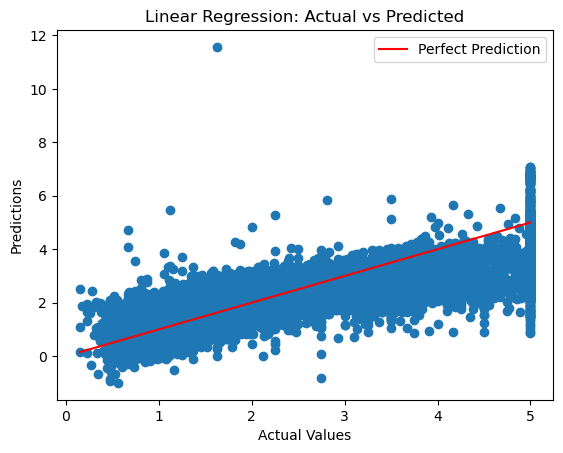

In [170]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)

min_value = min(y_test)
max_value = max(y_test)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    label="Perfect Prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predictions")
plt.title("Linear Regression: Actual vs Predicted")
plt.legend()
plt.show()

The red line or The Perfect Prediction line: `y = x` 

$ Our graph is not perfect accourding to Evaluation models 

# Observation:
- The Linear Regression model captures the general relationship between
- the actual and predicted values. However, the predictions show a
- considerable spread around the perfect prediction line, with some
- large errors and underprediction for higher target values.

---

# `Polynomial`

In [171]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

model.fit(x_train,y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [172]:
import numpy as np

predictions = model.predict(x_test)

print("Prediction min:", predictions.min())
print("Prediction max:", predictions.max())

print("MAE:", mean_absolute_error(y_test, predictions))
print("MSE:", mean_squared_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R2:", r2_score(y_test, predictions))

Prediction min: -893.0549250212215
Prediction max: 17.646758389367072
MAE: 0.5152126499303936
MSE: 49.20896660608726
RMSE: 7.014910306346565
R2: -36.05668487562685


In [173]:
predictions = model.predict(x_test)
predictions

array([0.74369753, 1.73620464, 3.83149788, ..., 1.44783818, 2.1228394 ,
       2.48003707])

In [174]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,predictions)
mae

0.5152126499303936

In [175]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,predictions)
mse

49.20896660608726

In [176]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test,predictions)
rmse

7.014910306346565

In [177]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,predictions)
r2

-36.05668487562685

In [178]:
linear_results = {
    "MAE": 0.529593955305815,
    "MSE": 0.5218435360402411,
    "RMSE": 0.722387386407211,
    "R2": 0.6070270765036975
}

polynomial_results = {
    "MAE": 0.5152126499303936,
    "MSE": 49.20896660608726,
    "RMSE":7.014910306346565,
    "R2": -36.05668487562685
}

In [179]:
import pandas as pd

comparison = pd.DataFrame({
    "Linear Regression": linear_results,
    "Polynomial Regression": polynomial_results
})

comparison

,Linear Regression,Polynomial Regression
MAE,0.529594,0.515213
MSE,0.521844,49.208967
RMSE,0.722387,7.014910
R2,0.607027,-36.056685


In [180]:
print(len(y_test))
print(len(predictions))

16512
16512


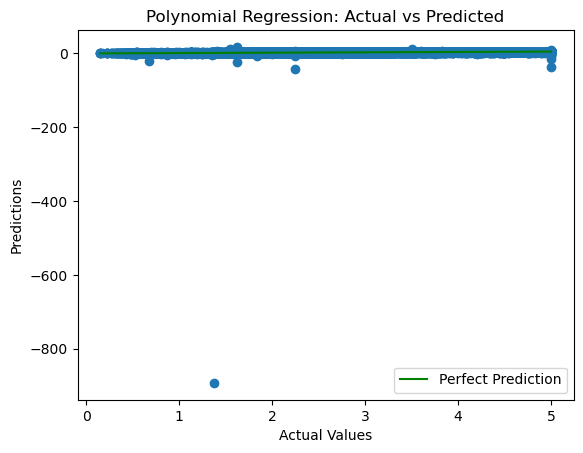

In [181]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)

min_value = min(y_test)
max_value = max(y_test)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="green",
    label="Perfect Prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predictions")
plt.title("Polynomial Regression: Actual vs Predicted")
plt.legend()
plt.show()


In [182]:
predictions[predictions < -100]

array([-893.05492502])

In [183]:
sum(predictions < -100)

np.int64(1)

I found that `Polynomial Regression` can produce extreme predictions when polynomial features become very large, especially without feature scaling; in my case, one prediction reached −893, which greatly increased MSE and RMSE and made R² negative, so I learned to always inspect predictions and visualizations instead of relying on a single evaluation metric.**


The solution is to `scale the features before applying PolynomialFeatures`, preferably using a Pipeline, so the polynomial terms don't become excessively large:

In [184]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2),
    LinearRegression()
)

model.fit(x_train, y_train)

predictions = model.predict(x_test)

In [185]:
mean_absolute_error(y_test, predictions)

0.5152126432347797

In [186]:
mean_squared_error(y_test, predictions)

49.20896163964564

In [187]:
np.sqrt(mean_squared_error(y_test, predictions))


np.float64(7.014909952354745)

In [188]:
r2_score(y_test, predictions)

-36.05668113566085

## Opps! Scalling doesn't solve this problem

In [189]:
predictions = model.predict(x_test)

print(predictions.min())
print(predictions.max())

-893.0548797037554
17.64675811502413


In [190]:
print(x_train.shape)
print(x_test.shape)

(4128, 8)
(16512, 8)


I made a mistake in the `train_test_split()` because I used `train_size=0.2`, which means **20% of the data is used for training and the remaining 80% for testing**, so I got `x_train = 4128` and `x_test = 16512`; what I actually wanted was **80% training and 20% testing**, so I should use `test_size=0.2` (or `train_size=0.8`), giving me `x_train = 16512` and `x_test = 4128`.


# Let's retrain and retest again

In [191]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [192]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

model.fit(x_train,y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [193]:
predictions = model.predict(x_test)
predictions

array([0.55399752, 1.75118568, 3.49237926, ..., 4.57436346, 1.03279138,
       1.92414298])

In [194]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,predictions)
mae

0.4670009307822192

In [195]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,predictions)
mse

0.46430148748694655

In [196]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test,predictions)
rmse

0.6813967181363193

In [197]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test,predictions)
r2

0.645682000660414

In [198]:
linear_results = {
    "MAE": 0.529593955305815,
    "MSE": 0.5218435360402411,
    "RMSE": 0.722387386407211,
    "R2": 0.6070270765036975
}

polynomial_results = {
    "MAE": mae,
    "MSE": mse,
    "RMSE":rmse,
    "R2": r2
}

In [199]:
comparison = pd.DataFrame({
    "Linear Regression": linear_results,
    "Polynomial Regression": polynomial_results
})

comparison

,Linear Regression,Polynomial Regression
MAE,0.529594,0.467001
MSE,0.521844,0.464301
RMSE,0.722387,0.681397
R2,0.607027,0.645682


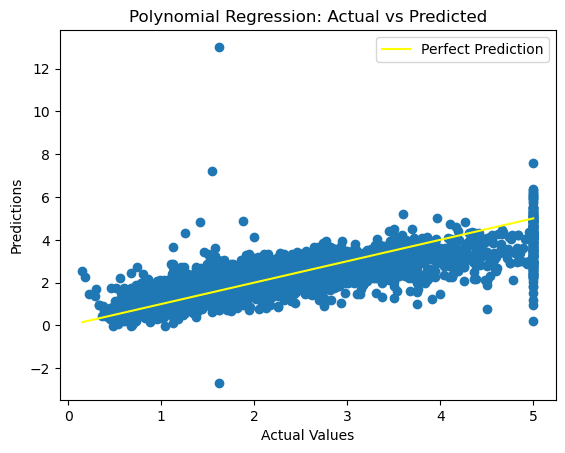

In [200]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)

min_value = min(y_test)
max_value = max(y_test)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="yellow",
    label="Perfect Prediction"
)

plt.xlabel("Actual Values")
plt.ylabel("Predictions")
plt.title("Polynomial Regression: Actual vs Predicted")
plt.legend()
plt.show()


# The Observation:
# `Polynomial Regression (degree=2)` performed better than Linear Regression on the test set, achieving lower MAE, MSE, and RMSE and a higher R² score. This suggests that adding quadratic terms helped the model capture some nonlinear relationships in the data.

# `Ridge`

In [201]:
from sklearn.datasets import load_diabetes

data = load_diabetes(as_frame=True)
df = data.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [202]:
df.shape

(442, 11)

In [203]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [204]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


In [205]:
x = df.drop("target",axis=1)
y=df["target"]

In [206]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test =train_test_split(
    x,
    y,
    train_size=0.2,
    random_state=42
)

In [207]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=0.5)
ridge_model.fit(x_train,y_train)

Ridge(alpha=0.5)

In [208]:
print("Coefficients:", ridge_model.coef_)
print("Intercept:", ridge_model.intercept_)

Coefficients: [ -1.96205823 -26.74058495 188.72454964 186.49749555  48.90687342
  27.99729711 -61.65545018  62.14841735 123.45384994  66.85757428]
Intercept: 140.91303229501816


In [209]:
predictions = ridge_model.predict(x_test)
predictions

array([152.08648189, 144.54343699, 148.367707  , 199.98214791,
       139.94300164, 133.34131707, 186.71914539, 175.46339937,
       113.36032682, 136.89051674, 124.34888459, 124.55448979,
        99.03617471, 172.11154708, 123.69810398, 128.79039104,
       174.80633065, 187.36563558, 146.44759237, 172.83295434,
       150.6818705 , 117.80707162, 109.61616253, 160.99965037,
       138.45553802, 148.02067937, 157.77427275, 150.01444812,
        95.14789652, 136.6066876 , 149.68420678, 119.954925  ,
       131.9282787 , 154.31035431, 149.41493138, 172.49167879,
       132.02585036, 137.85559109, 148.89681752, 100.36338948,
       114.44558565, 132.04568319, 136.44403534, 142.30564147,
       150.03747027, 110.01913412, 106.23350203, 113.3481918 ,
        99.45508682, 135.33759834, 125.39575222, 100.72501033,
       130.16436292, 121.22628586, 169.40426914, 136.65126343,
       124.05796669, 155.86079514, 121.2632677 ,  97.12919412,
       163.24117817, 148.02804602, 132.82461444, 135.59

In [210]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
mae

53.54425975089179

In [211]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
mse

4152.275692660577

In [212]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, predictions)
rmse

64.43815401344592

In [213]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
r2

0.30423200391746785

In [214]:
Linear_Regression_Results = {
    "MAE": 0.529594,
    "MSE": 0.521844,
    "RMSE": 0.722387,
    "R2": 0.607027
}

Polynomail_Regression_Results = {
     "MAE": 0.467001,
     "MSE": 0.464301,
     "RMSE": 0.681397,
     "R2": 0.645682
}

Ridge_Results = {
     "MAE": mae,
     "MSE": mse,
     "RMSE": rmse,
     "R2": r2
}

In [215]:
Comparison_3_Models = pd.DataFrame({
    "Linear_Regression": Linear_Regression_Results,
        "Polynomial_Regression": Polynomail_Regression_Results,
        "Ridge": Ridge_Results
})

Comparison_3_Models

,Linear_Regression,Polynomial_Regression,Ridge
MAE,0.529594,0.467001,53.544260
MSE,0.521844,0.464301,4152.275693
RMSE,0.722387,0.681397,64.438154
R2,0.607027,0.645682,0.304232


## Choosing the Best `alpha`

At first, I used a random value for `alpha`:

```python
Ridge(alpha=0.5)

However, the evaluation metrics became extremely poor compared with the other models.

This made me realize that alpha is not a value that should be chosen randomly.

Instead, alpha is a hyperparameter that needs to be tuned.

The goal is to find the value of alpha that gives the best performance on validation data.



In [216]:
from sklearn.linear_model import RidgeCV

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

model = RidgeCV(alphas=alphas)

model.fit(x_train,y_train)

model.alpha_

np.float64(0.1)

In [217]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=0.001)
ridge_model.fit(x_train,y_train)

Ridge(alpha=0.001)

In [218]:
predictions = ridge_model.predict(x_test)
predictions

array([132.70241553, 170.47456429, 137.18609052, 240.33550869,
       114.72595471,  98.66981302, 255.92945507, 190.30839808,
        63.52317769, 124.91190373, 104.77828553, 123.83270669,
        78.13818872, 187.16185733,  92.18468349, 126.69127423,
       196.41331966, 226.40361658, 193.33819196, 207.73901433,
       184.58684135,  77.24461845,  72.21505222, 181.21883016,
       160.95412912, 156.43130455, 195.14232217, 159.35647896,
        56.8115131 , 107.85002869, 160.3613148 ,  97.36896942,
       110.28412837, 155.03764979, 134.79394512, 223.65058989,
       104.40634661, 104.42859879, 114.80515553,  57.39126209,
        70.055016  , 121.68555788, 143.8013019 ,  97.00176627,
       157.12886089,  84.27715941,  72.22208051,  97.65000043,
        58.57464357, 147.82922722, 149.59182986,  66.24905808,
       101.77378829,  98.1419085 , 177.2651993 , 172.81629041,
        86.46669835, 193.2698322 , 114.2104908 ,  57.79113808,
       169.63035437, 177.81548418, 149.5176694 , 120.87

In [219]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
mae

47.00714137169044

In [220]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
mse

3364.564531943549

In [221]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, predictions)
rmse

58.00486645052766

In [222]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
r2

0.4362232916714751

In [223]:
Linear_Regression_Results = {
    "MAE": 0.529594,
    "MSE": 0.521844,
    "RMSE": 0.722387,
    "R2": 0.607027
}

Polynomail_Regression_Results = {
     "MAE": 0.467001,
     "MSE": 0.464301,
     "RMSE": 0.681397,
     "R2": 0.645682
}

Ridge_Results = {
     "MAE": mae,
     "MSE": mse,
     "RMSE": rmse,
     "R2": r2
}

In [224]:
Comparison_3_Models = pd.DataFrame({
    "Linear_Regression": Linear_Regression_Results,
        "Polynomial_Regression": Polynomail_Regression_Results,
        "Ridge": Ridge_Results
})

Comparison_3_Models

,Linear_Regression,Polynomial_Regression,Ridge
MAE,0.529594,0.467001,47.007141
MSE,0.521844,0.464301,3364.564532
RMSE,0.722387,0.681397,58.004866
R2,0.607027,0.645682,0.436223


In [225]:
print("RidgeCV alpha:", model.alpha_)

print("RidgeCV coef:", model.coef_)
print("RidgeCV intercept:", model.intercept_)

RidgeCV alpha: 0.1
RidgeCV coef: [-38.42837958 -94.70001356 401.62511073 376.16450038  36.72066953
 -12.45917807 -90.62775267  56.88682646 208.10170002  54.29661449]
RidgeCV intercept: 140.94500206575293


In [226]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

print("Linear coef:", linear_model.coef_)
print("Linear intercept:", linear_model.intercept_)

Linear coef: [ -83.38136722 -139.35912238  623.57139726  529.92557356   70.65799882
  -82.23243476 -162.30347149  -76.32052713  277.60668667  -49.00997846]
Linear intercept: 140.49080683761522


In [227]:
print("X train shape:", x_train.shape)
print("X test shape:", x_test.shape)
print("y train shape:", y_train.shape)
print("y test shape:", y_test.shape)

X train shape: (88, 10)
X test shape: (354, 10)
y train shape: (88,)
y test shape: (354,)


In [228]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [229]:
x_train_scaled.mean(axis=0)
x_train_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [230]:
from sklearn.linear_model import RidgeCV

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_cv = RidgeCV(alphas=alphas)

ridge_cv.fit(x_train_scaled, y_train)

print("Best alpha:", ridge_cv.alpha_)

Best alpha: 10.0


In [231]:
ridge_predictions = ridge_cv.predict(x_test_scaled)

In [232]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, ridge_predictions)
mse = mean_squared_error(y_test, ridge_predictions)
rmse = root_mean_squared_error(y_test, ridge_predictions)
r2 = r2_score(y_test, ridge_predictions)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 46.74292249811964
MSE: 3313.2671380904476
RMSE: 57.56098625015426
R²: 0.44481883964737545


## Debugging: Unexpected Ridge Results

At first, the Ridge Regression results were extremely different from the Linear and Polynomial Regression results.

I initially thought that the problem was caused by the `alpha` value or feature scaling.

After debugging, I found the real problem:

> **I was using a different dataset for Ridge Regression than the one I used for Linear and Polynomial Regression.**

Therefore, comparing their evaluation metrics was not valid.

### Lesson learned

When comparing different ML models, they should be evaluated on:

- The same dataset
- The same train/test split
- The same target variable
- The same evaluation metrics

Otherwise, the comparison is not fair.
